<center>

$\Huge \textbf{Universidad Nacional Autónoma de México}$  
$\Huge \textbf{Facultad de Ciencias}$  
<p align="center">
  <img src="https://www.icat.unam.mx/wp-content/uploads/2021/11/Copia-de-LogoUNAM.-Azul.-Fondo-transparente.png" alt="UNAM" width="200"/>
</p>

<hr style="height:3px; background-color:#0B6E4F; border:none;"/>


$\LARGE \textbf{Inteligencia Artificial}$  

$\Large \textit{Laboratorio 2.3}$  


\begin{array}{rl}
\textbf{Docente:} & Dra. Jessica Sarahi Méndez Rincón \\[6pt]
\textbf{Ayudante de laboratorio:} & Diego Eduardo Peña Villegas \\[6pt]
\textbf{Alumna:} & Marisol Luna Méndez \\[6pt]
\textbf{Fecha de realización:} & 25/02/2026
\end{array}

</center>

In [ ]:
!pip install Word2Vec

In [ ]:
!pip install gensim

# Algoritmo  de Distancia de Levenshtein es un  

In [ ]:
def levenshtein_futbol(palabra_a, palabra_b):
    """
    Calcula la distancia de edición entre dos términos.
    Ejemplo: 'Messi' vs 'Messi' (0), 'Gol' vs 'Gool' (1)
    """
    n = len(palabra_a)
    m = len(palabra_b)

    # 1. Crear la matriz inicializada en ceros
    matriz = [[0 for _ in range(m + 1)] for _ in range(n + 1)]

    # 2. Casos base: transformar cadena a vacío o viceversa
    for i in range(n + 1):
        matriz[i][0] = i
    for j in range(m + 1):
        matriz[0][j] = j

    # 3. Llenado de la matriz con programación dinámica
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            # Si los caracteres son iguales, el costo es 0
            if palabra_a[i-1] == palabra_b[j-1]:
                costo = 0
            else:
                costo = 1

            # Buscamos el mínimo entre las 3 operaciones posibles
            matriz[i][j] = min(
                matriz[i-1][j] + 1,      # Eliminación
                matriz[i][j-1] + 1,      # Inserción
                matriz[i-1][j-1] + costo # Sustitución
            )

    return matriz[n][m]

# --- PRUEBA PARA CLASE ---
termino_busqueda = "Gool"
termino_real = "Gol"

distancia = levenshtein_futbol(termino_busqueda, termino_real)
print(f"La distancia entre '{termino_busqueda}' y '{termino_real}' es: {distancia}")
# Resultado esperado: 1

La distancia entre 'Gool' y 'Gol' es: 1


#Word2Vec

Ejemplo en Código (Python + Gensim)

Usaríamos la librería gensim. Imaginemos que ya entrenamos el modelo con noticias de la Liga MX o de la Champions:

In [ ]:
from gensim.models import Word2Vec

# Un 'corpus' de ejemplo (muy simplificado)
entrenamiento_futbol = [
    ["el", "delantero", "pateó", "al", "arco"],
    ["el", "atacante", "pateó", "al", "marco"],
    ["el", "portero", "detuvo", "el", "balón"],
    ["el", "arquero", "atajó", "la", "pelota"]
]

# Entrenamos el modelo
modelo = Word2Vec(sentences=entrenamiento_futbol, vector_size=100, window=2, min_count=1)

# 1. Encontrar similitud
similitud = modelo.wv.similarity('delantero', 'atacante')
print(f"Similitud entre delantero y atacante: {similitud:.2f}")

# 2. ¿Cuál no encaja en la alineación?
no_encaja = modelo.wv.doesnt_match(["delantero", "atacante", "arquero", "pizza"])
print(f"El infiltrado es: {no_encaja}")

Similitud entre delantero y atacante: -0.16
El infiltrado es: atacante


# Word2Vec Algoritmo desde Cero

In [ ]:
import numpy as np

def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum(axis=0)

class Word2VecSimplified:
    def __init__(self, vocab_size, embed_dist):
        self.n = embed_dist # Dimensiones
        self.v = vocab_size # Tamaño vocabulario
        # Inicialización de pesos (He initialization)
        self.w1 = np.random.randn(self.v, self.n)
        self.w2 = np.random.randn(self.n, self.v)

    def forward(self, x):
        # x es un vector one-hot o el índice de la palabra
        h = self.w1[x]
        u = np.dot(h, self.w2)
        y_c = softmax(u)
        return y_c, h, u

    def backward(self, e, h, x):
        # Gradientes para actualizar los pesos
        dw2 = np.outer(h, e)
        dw1 = np.dot(self.w2, e.T)

        # Actualización simple (tasa de aprendizaje 0.01)
        self.w2 = self.w2 - (0.01 * dw2)
        self.w1[x] = self.w1[x] - (0.01 * dw1.T)

# Ejemplo de uso conceptual:
# 1. Definimos vocabulario: {'gol': 0, 'messi': 1, 'futbol': 2}
# 2. Si entra 'messi' (index 1) y el contexto es 'gol' (index 0)
modelo = Word2VecSimplified(vocab_size=3, embed_dist=2)
y_pred, h, u = modelo.forward(1)

# El error es (predicción - real) donde real es un one-hot del contexto
error = y_pred.copy()
error[0] -= 1

modelo.backward(error, h, 1)
print("Vector actualizado de 'Messi':", modelo.w1[1])

Vector actualizado de 'Messi': [ 1.21099476 -0.0923321 ]


# Sobel

In [ ]:
import numpy as np

def sobel_filter(image):
    # Kernels de Sobel
    Gx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
    Gy = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]])

    rows, cols = image.shape
    output = np.zeros((rows, cols))

    # Aplicar padding simple para evitar errores en bordes
    padded_img = np.pad(image, (1, 1), mode='constant')

    for i in range(rows):
        for j in range(cols):
            region = padded_img[i:i+3, j:j+3]
            gx = np.sum(region * Gx)
            gy = np.sum(region * Gy)
            output[i, j] = np.sqrt(gx**2 + gy**2)

    # Normalización a 0-255
    output = (output / output.max()) * 255
    return output.astype(np.uint8)

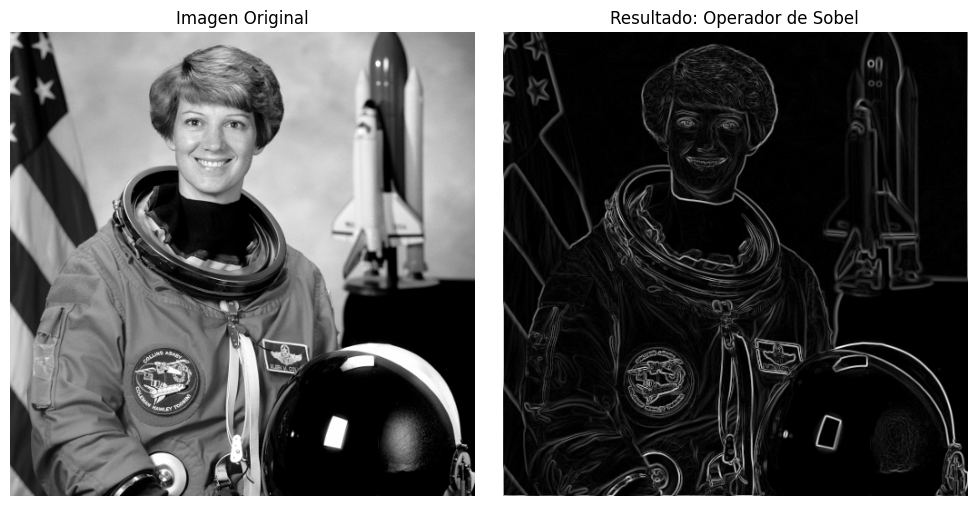

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color

# 1. Cargar una imagen de muestra (ej. astronauta) y convertir a gris
image = color.rgb2gray(data.astronaut())

# 2. Aplicar la función sobel_filter que definimos anteriormente
# (Asegúrate de que la función sobel_filter esté definida en el mismo script)
bordes = sobel_filter(image)

# 3. Visualización comparativa
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Imagen Original")
plt.imshow(image, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Resultado: Operador de Sobel")
plt.imshow(bordes, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

#SIFT

In [ ]:
import cv2
import numpy as np
from skimage import data, color, img_as_ubyte # Importamos esta utilidad

def extraer_caracteristicas_sift(imagen_uint8):
    sift = cv2.SIFT_create()
    kp, des = sift.detectAndCompute(imagen_uint8, None)
    return kp, des

# 1. Cargar imagen
image_float = color.rgb2gray(data.astronaut())

# 2. CORRECCIÓN: Convertir de float (0.0-1.0) a uint8 (0-255)
image_uint8 = img_as_ubyte(image_float)

# 3. Ahora sí, ejecutar
kp, des = extraer_caracteristicas_sift(image_uint8)

print(f"Puntos clave encontrados: {len(kp)}")
print(f"Dimensión del descriptor: {des.shape}") # Nota: des es una matriz completa

Puntos clave encontrados: 1100
Dimensión del descriptor: (1100, 128)


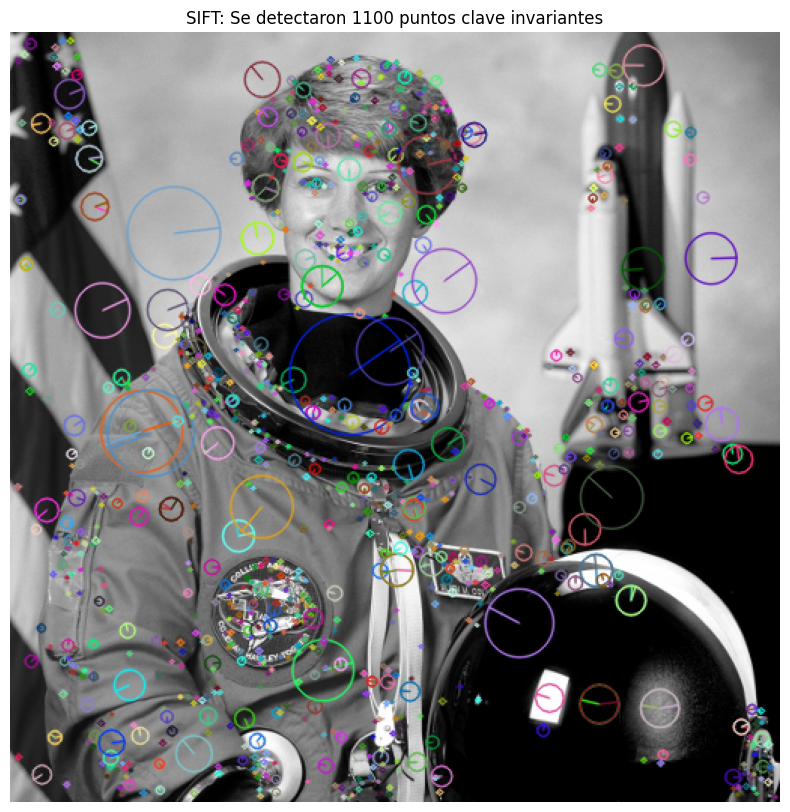

In [ ]:
import cv2
import matplotlib.pyplot as plt
# (Asume que ya tienes 'image_uint8', 'kp', and 'des' de la ejecución anterior)

# 1. Dibujar los puntos clave sobre la imagen original
# Usamos DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS para que dibuje
# la orientación y el tamaño de cada punto (la "riqueza" de SIFT).
imagen_con_sift = cv2.drawKeypoints(image_uint8, kp, None,
                                   flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# 2. Visualización
plt.figure(figsize=(10, 10))
plt.imshow(imagen_con_sift)
plt.title(f"SIFT: Se detectaron {len(kp)} puntos clave invariantes")
plt.axis('off')
plt.show()

#Arquitectura del SIFT desde cero

1. Leer imagen
2. Convertir a escala de grises
3. Generar pirámide Gaussiana
4. Generar Difference of Gaussians (DoG)
5. Detectar extremos locales
6. Filtrar keypoints débiles
7. Calcular orientación
8. Construir descriptor
9. Matching entre imágenes

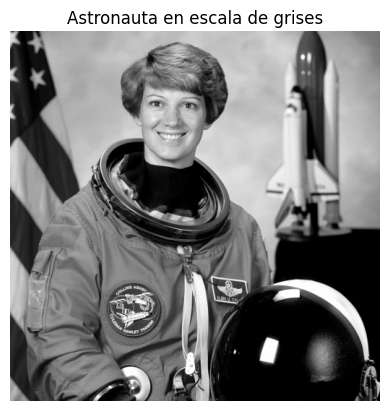

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, img_as_ubyte # Importamos esta utilidad

# 1. Cargar la imagen de la astronauta (viene en formato RGB y float por defecto)
image_astronaut = data.astronaut()

# 2. Convertirla a escala de grises usando skimage
gray_float = color.rgb2gray(image_astronaut)

# 3. Convertir de float (0.0-1.0) a uint8 (0-255) para que sea compatible con OpenCV si lo necesitas
gray = img_as_ubyte(gray_float)

# 4. Mostrar la imagen con Matplotlib
plt.imshow(gray, cmap='gray')
plt.title("Astronauta en escala de grises")
plt.axis("off")
plt.show()

In [ ]:
def gaussian_kernel(size, sigma):
    ax = np.arange(-(size // 2), size // 2 + 1)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    kernel = kernel / np.sum(kernel)
    return kernel

In [ ]:
kernel = gaussian_kernel(5, 1)

print(kernel)

[[0.00296902 0.01330621 0.02193823 0.01330621 0.00296902]
 [0.01330621 0.0596343  0.09832033 0.0596343  0.01330621]
 [0.02193823 0.09832033 0.16210282 0.09832033 0.02193823]
 [0.01330621 0.0596343  0.09832033 0.0596343  0.01330621]
 [0.00296902 0.01330621 0.02193823 0.01330621 0.00296902]]


In [ ]:
def convolution(image, kernel):
    h, w = image.shape
    kh, kw = kernel.shape
    pad_h = kh // 2
    pad_w = kw // 2
    padded = np.pad(
        image,
        ((pad_h, pad_h), (pad_w, pad_w)),
        mode='constant'
    )
    output = np.zeros_like(image, dtype=np.float32)
    for i in range(h):
        for j in range(w):
            region = padded[i:i+kh, j:j+kw]
            output[i, j] = np.sum(region * kernel)
    return output

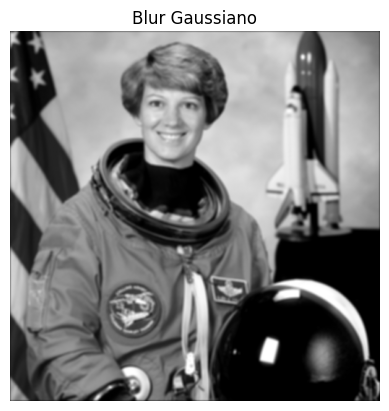

In [ ]:
kernel = gaussian_kernel(5, 1.6)

blur = convolution(gray, kernel)

plt.imshow(blur, cmap='gray')
plt.title("Blur Gaussiano")
plt.axis("off")
plt.show()

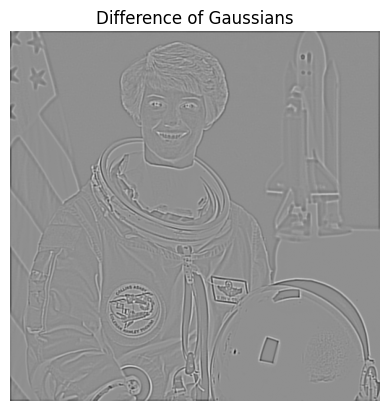

In [ ]:
blur1 = convolution(gray, gaussian_kernel(5, 1))
blur2 = convolution(gray, gaussian_kernel(5, 2))
dog = blur2 - blur1
plt.imshow(dog, cmap='gray')
plt.title("Difference of Gaussians")
plt.axis("off")
plt.show()

In [ ]:
def detect_keypoints(dog, threshold=5):
    keypoints = []
    h, w = dog.shape
    for i in range(1, h-1):
        for j in range(1, w-1):
            patch = dog[i-1:i+2, j-1:j+2]
            center = dog[i, j]
            if center == np.max(patch) or center == np.min(patch):
                if abs(center) > threshold:
                    keypoints.append((j, i))
    return keypoints

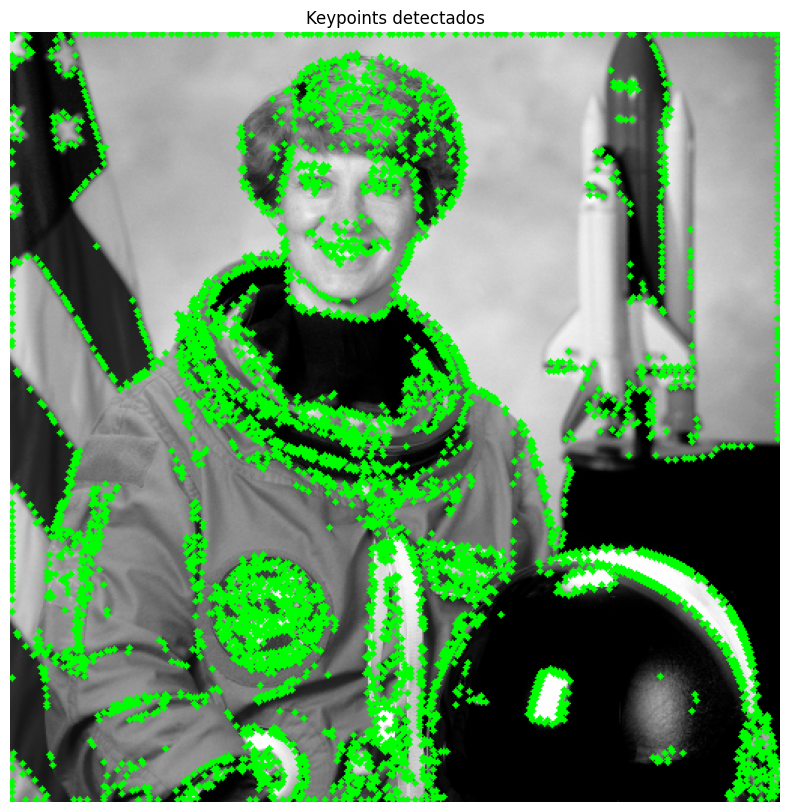

In [ ]:
keypoints = detect_keypoints(dog)
img_points = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
for x, y in keypoints:
    cv2.circle(img_points, (x, y), 2, (0,255,0), -1)
plt.figure(figsize=(10,10))
plt.imshow(img_points)
plt.title("Keypoints detectados")
plt.axis("off")
plt.show()

In [ ]:
def compute_gradients(image):

    image = image.astype(np.float32)

    h, w = image.shape

    magnitude = np.zeros((h, w), dtype=np.float32)
    orientation = np.zeros((h, w), dtype=np.float32)

    for i in range(1, h-1):
        for j in range(1, w-1):

            # derivadas
            dx = image[i, j+1] - image[i, j-1]
            dy = image[i+1, j] - image[i-1, j]

            # magnitud
            mag = np.sqrt(dx**2 + dy**2)

            # orientación
            angle = np.arctan2(dy, dx)

            magnitude[i, j] = mag
            orientation[i, j] = angle

    return magnitude, orientation

In [ ]:
magnitude, orientation = compute_gradients(blur)

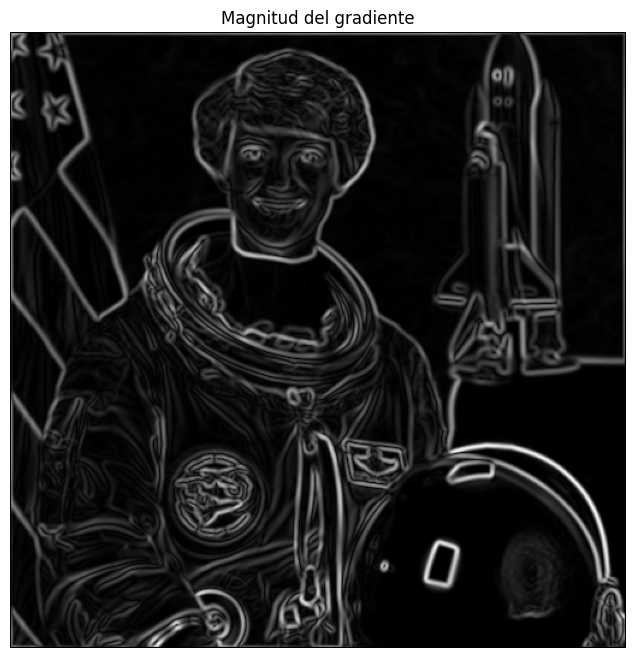

In [ ]:
plt.figure(figsize=(8,8))

plt.imshow(magnitude, cmap='gray')
plt.title("Magnitud del gradiente")
plt.axis("off")
plt.show()

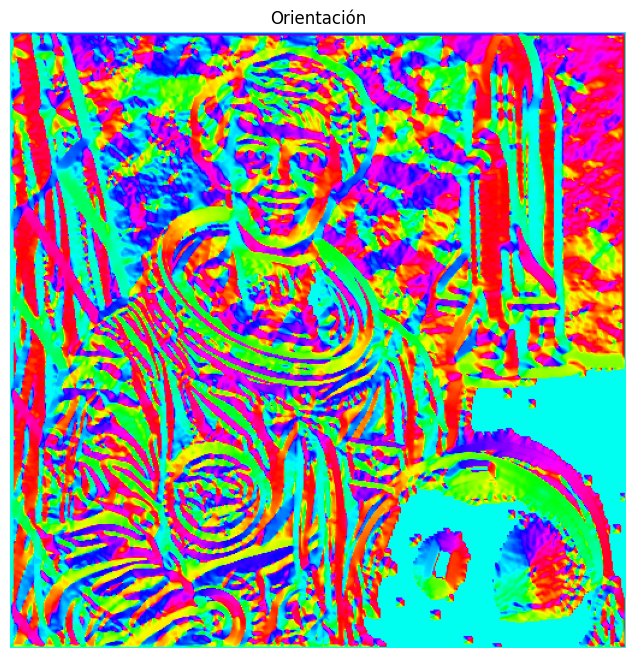

In [ ]:
plt.figure(figsize=(8,8))
plt.imshow(orientation, cmap='hsv')
plt.title("Orientación")
plt.axis("off")
plt.show()

In [ ]:
def orientation_histogram(
    magnitude,
    orientation,
    x,
    y,
    radius=8,
    bins=36
):

    hist = np.zeros(bins)
    h, w = magnitude.shape
    for i in range(-radius, radius):
        for j in range(-radius, radius):
            yi = y + i
            xj = x + j
            if yi < 0 or yi >= h:
                continue
            if xj < 0 or xj >= w:
                continue
            mag = magnitude[yi, xj]
            angle = orientation[yi, xj]
            angle_deg = np.degrees(angle) % 360
            bin_idx = int(angle_deg / (360 / bins))
            hist[bin_idx] += mag

    return hist

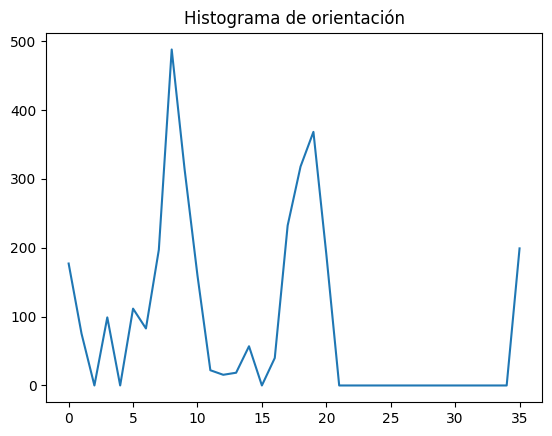

In [ ]:
x, y = keypoints[0]

hist = orientation_histogram(
    magnitude,
    orientation,
    x,
    y
)

plt.plot(hist)
plt.title("Histograma de orientación")
plt.show()

In [ ]:
def simple_descriptor(
    magnitude,
    orientation,
    x,
    y,
    window=16,
    bins=8
):

    descriptor = []

    step = window // 4

    for i in range(4):
        for j in range(4):
            hist = np.zeros(bins)
            for wi in range(step):
                for wj in range(step):
                    yi = y + i*step + wi
                    xj = x + j*step + wj
                    if yi >= magnitude.shape[0]:
                        continue
                    if xj >= magnitude.shape[1]:
                        continue
                    mag = magnitude[yi, xj]
                    angle = orientation[yi, xj]
                    angle_deg = np.degrees(angle) % 360
                    bin_idx = int(angle_deg / (360 / bins))
                    hist[bin_idx] += mag
            descriptor.extend(hist)
    descriptor = np.array(descriptor)

    # normalización
    descriptor = descriptor / (np.linalg.norm(descriptor) + 1e-7)

    return descriptor

In [ ]:
descriptor = simple_descriptor(
    magnitude,
    orientation,
    x,
    y
)

print(descriptor.shape)

(128,)


In [ ]:
def generate_descriptors(
    magnitude,
    orientation,
    keypoints
):

    descriptors = []
    valid_keypoints = []
    for x, y in keypoints:

        # evitar bordes
        if y + 16 >= magnitude.shape[0]:
            continue
        if x + 16 >= magnitude.shape[1]:
            continue
        descriptor = simple_descriptor(
            magnitude,
            orientation,
            x,
            y
        )
        descriptors.append(descriptor)
        valid_keypoints.append((x, y))
    return np.array(descriptors), valid_keypoints

In [ ]:
descriptors1, keypoints1 = generate_descriptors(
    magnitude,
    orientation,
    keypoints
)

In [ ]:
img2 = cv2.imread("220px-Dante_Alighieri01.jpg")
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

In [ ]:
blur2 = convolution(
    gray2,
    gaussian_kernel(5, 1.6)
)

mag2, ori2 = compute_gradients(blur2)

dog2 = blur2 - convolution(
    gray2,
    gaussian_kernel(5, 1)
)

kp2 = detect_keypoints(dog2)

descriptors2, keypoints2 = generate_descriptors(
    mag2,
    ori2,
    kp2
)

In [ ]:
def euclidean_distance(a, b):

    return np.linalg.norm(a - b)

In [ ]:
def match_descriptors(
    desc1,
    desc2,
    threshold=0.5
):
    matches = []
    for i, d1 in enumerate(desc1):
        best_distance = float("inf")
        best_j = -1
        for j, d2 in enumerate(desc2):
            dist = euclidean_distance(d1, d2)
            if dist < best_distance:
                best_distance = dist
                best_j = j
        if best_distance < threshold:
            matches.append((i, best_j, best_distance))
    return matches

In [ ]:
matches = match_descriptors(
    descriptors1,
    descriptors2
)

print("Matches:", len(matches))

Matches: 527


In [ ]:
def draw_matches(
    img1,
    img2,
    kp1,
    kp2,
    matches
):

    h1, w1 = img1.shape
    h2, w2 = img2.shape

    canvas = np.zeros(
        (max(h1, h2), w1 + w2, 3),
        dtype=np.uint8
    )

    canvas[:h1, :w1] = cv2.cvtColor(img1, cv2.COLOR_GRAY2BGR)
    canvas[:h2, w1:] = cv2.cvtColor(img2, cv2.COLOR_GRAY2BGR)
    for i, j, dist in matches:
        x1, y1 = kp1[i]
        x2, y2 = kp2[j]
        color = (0,255,0)
        cv2.circle(canvas, (x1, y1), 3, color, -1)
        cv2.circle(canvas, (x2+w1, y2), 3, color, -1)
        cv2.line(
            canvas,
            (x1, y1),
            (x2+w1, y2),
            color,
            1
        )

    return canvas

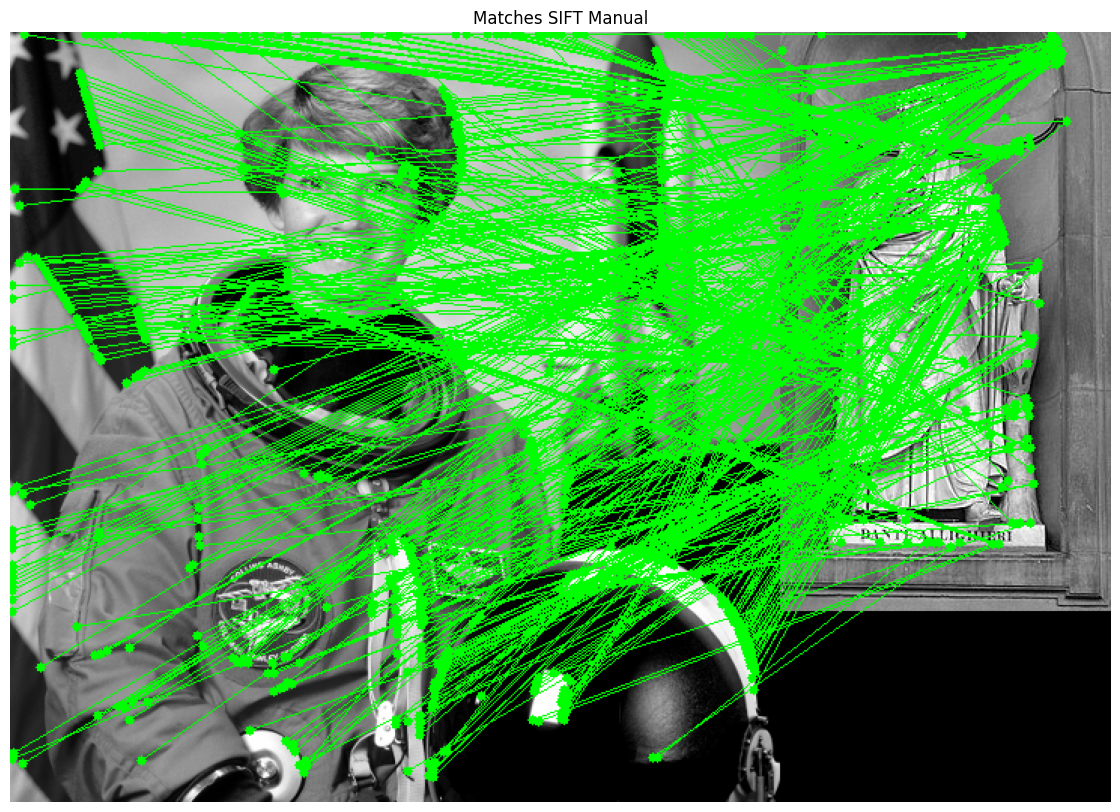

In [ ]:
matched_img = draw_matches(
    gray,
    gray2,
    keypoints1,
    keypoints2,
    matches
)

plt.figure(figsize=(15,10))
plt.imshow(matched_img)
plt.title("Matches SIFT Manual")
plt.axis("off")
plt.show()

# Detección y Mitigación de Sesgo Algorítmico

**Objetivos de Aprendizaje**

- Identificar y medir el sesgo en un conjunto de datos utilizando métricas de equidad (fairness metrics).

- Entrenar un clasificador base y evaluar su impacto dispar en un atributo protegido.

- Aplicar técnicas algorítmicas de mitigación (post-procesamiento o reducción) para balancear el modelo.

- Reflexionar sobre el costo en la precisión (accuracy) global al buscar un modelo más justo.

In [ ]:
!pip install fairlearn

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from fairlearn.metrics import MetricFrame, selection_rate, false_positive_rate, demographic_parity_difference
from fairlearn.reductions import ExponentiatedGradient, DemographicParity

# ==========================================
# 1. CONFIGURACIÓN Y GENERACIÓN DEL DATASET
# ==========================================
np.random.seed(42)
n_candidatos = 500

# Simulamos características de los solicitantes de crédito
ingresos = np.random.randint(15000, 80000, size=n_candidatos)
historial_crediticio = np.random.choice([0, 1], size=n_candidatos, p=[0.3, 0.7]) # 1 = Buen historial
genero = np.random.choice([0, 1], size=n_candidatos, p=[0.4, 0.6]) # 0 = Mujeres, 1 = Hombres

# Creamos un sesgo histórico intencional: A los hombres se les aprobaba más el crédito en el pasado
# independientemente de sus ingresos.
probabilidad_aprobacion = 0.3 * historial_crediticio + 0.4 * genero + 0.3 * (ingresos / 80000)
credito_aprobado = (probabilidad_aprobacion > 0.5).astype(int)

# Crear el DataFrame único
df = pd.DataFrame({
    'ingresos': ingresos,
    'historial': historial_crediticio,
    'genero_atributo_protegido': genero,
    'credito_aprobado_objetivo': credito_aprobado
})

# ==========================================
# 2. PREPARACIÓN DE DATOS (X, y) Y DIVISIÓN
# ==========================================
# Separamos las características (X) de la etiqueta que queremos predecir (y)
X = df[['ingresos', 'historial', 'genero_atributo_protegido']]
y = df['credito_aprobado_objetivo']

# Dividimos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Guardamos el atributo protegido de prueba por separado para Fairlearn
genero_test = X_test['genero_atributo_protegido']

print("✅ Dataset preparado y dividido correctamente.")
print(f"Tamaño de entrenamiento: {X_train.shape[0]} muestras. Tamaño de prueba: {X_test.shape[0]} muestras.\n")

# ==========================================
# 3. ENTRENAMIENTO DEL MODELO BASE (INJUSTO)
# ==========================================
modelo_base = DecisionTreeClassifier(max_depth=4, random_state=42)
modelo_base.fit(X_train, y_train)
preds_base = modelo_base.predict(X_test)

# Evaluamos el comportamiento del modelo base por género
metricas_interes = {
    'Exactitud (Accuracy)': accuracy_score,
    'Tasa de Aprobación': selection_rate,
    'Falsos Positivos (FPR)': false_positive_rate
}

marco_base = MetricFrame(
    metrics=metricas_interes,
    y_true=y_test,
    y_pred=preds_base,
    sensitive_features=genero_test
)

print("--- EVALUACIÓN DEL MODELO BASE (Por Grupo) ---")
print(marco_base.by_group)
print(f"Diferencia en la paridad demográfica: {demographic_parity_difference(y_test, preds_base, sensitive_features=genero_test):.4f}\n")

# ==========================================
# 4. MITIGACIÓN DEL SESGO (MODELO JUSTO)
# ==========================================
# Forzamos al algoritmo a aprender bajo la restricción de Paridad Demográfica
mitigador = ExponentiatedGradient(
    estimator=DecisionTreeClassifier(max_depth=4, random_state=42),
    constraints=DemographicParity()
)

# Entrenamos especificando cuál es la variable protegida en el set de entrenamiento
mitigador.fit(X_train, y_train, sensitive_features=X_train['genero_atributo_protegido'])
preds_justas = mitigador.predict(X_test)

# Evaluamos el comportamiento del nuevo modelo mitigado
marco_justo = MetricFrame(
    metrics=metricas_interes,
    y_true=y_test,
    y_pred=preds_justas,
    sensitive_features=genero_test
)

print("--- EVALUACIÓN DEL MODELO MITIGADO (Por Grupo) ---")
print(marco_justo.by_group)
print(f"Diferencia en la paridad demográfica post-mitigación: {demographic_parity_difference(y_test, preds_justas, sensitive_features=genero_test):.4f}\n")

# ==========================================
# 5. COMPARATIVA FINAL PARA EL ALUMNO
# ==========================================
print("--- COMPARATIVA GENERAL ---")
print(f"Modelo Base   -> Accuracy Global: {accuracy_score(y_test, preds_base):.2f} | Disparidad: {demographic_parity_difference(y_test, preds_base, sensitive_features=genero_test):.2f}")
print(f"Modelo Justo  -> Accuracy Global: {accuracy_score(y_test, preds_justas):.2f} | Disparidad: {demographic_parity_difference(y_test, preds_justas, sensitive_features=genero_test):.2f}")

✅ Dataset preparado y dividido correctamente.
Tamaño de entrenamiento: 350 muestras. Tamaño de prueba: 150 muestras.

--- EVALUACIÓN DEL MODELO BASE (Por Grupo) ---
                           Exactitud (Accuracy)  Tasa de Aprobación  \
genero_atributo_protegido                                             
0                                           1.0            0.352941   
1                                           1.0            0.963415   

                           Falsos Positivos (FPR)  
genero_atributo_protegido                          
0                                             0.0  
1                                             0.0  
Diferencia en la paridad demográfica: 0.6105

--- EVALUACIÓN DEL MODELO MITIGADO (Por Grupo) ---
                           Exactitud (Accuracy)  Tasa de Aprobación  \
genero_atributo_protegido                                             
0                                      0.382353            0.970588   
1                               

El Diagnóstico del Modelo Base: Una Injusticia "Perfecta"
Al observar el primer bloque, notamos algo alarmante:

La ilusión del 100% de Exactitud: El modelo base tiene un Accuracy perfecto de 1.0 (100%). Para un alumno descuidado, este sería el "modelo ideal".

La cruda realidad del sesgo: Al desagregar los datos, la Tasa de Aprobación para el grupo 1 (Hombres) es del 96.3%, mientras que para el grupo 0 (Mujeres) es apenas del 35.2%.

**Conclusión**: El modelo es "perfectamente exacto" únicamente porque aprendió a replicar a la perfección los prejuicios históricos del pasado. Logró la máxima eficiencia técnica a costa de una enorme injusticia social (una disparidad del 0.61).

<hr/>
<footer style="text-align:center; font-size:12px; color:gray;">
© 2026 UNAM Facultado de Ciencias – Todos los derechos reservados

</footer>